# BUSN 32120 Final Project
## Shrinkflation in Household Cleaning Products

Group 34: Ridhi Agarwal

### 0 | Introduction

The data presented are intended for the audience of **legal counsel investigating potential shrinkflation practices** in the consumer goods industry. Our hypothetical client represents a consumer goods company preparing for meida and legal scrutiny in the wake of consumer advocacy group activism alleging "shrikflation" practices across many of their competitors. In this hypothetical case, we were hired to conduct analyses on macroeconomic data relevant to class-wide (i.e., uniform) consumer impact. The analysis provides quantitative evidence to support litigation by identifying pricing patterns that may indicate:
- Disproportionate price increases relative to input costs
- Price increases that outpace general inflation
- Timing of price changes that may correlate with reduced product sizes

Consumer advocacy groups and legal teams have alleged that major household cleaning product manufacturers engaged in "shrinkflation" practices between 2019-2024, reducing package sizes while maintaining or increasing prices. This practice effectively raises the per-unit cost to consumers without transparent disclosure.

Our analysis aims to:
1. Quantify the extent to which cleaning product prices have increased beyond general inflation
2. Compare cleaning product inflation to producer costs and other consumer goods
3. Identify key time periods where pricing divergences occurred

### 1 | Data sourcing

All data are sourced from the **Federal Reserve Economic Data (FRED)** and the **Bureau of Labor Statistics (BLS)**. The data are pre-saved as CSV files in this repository so the notebook runs on any environment — local Jupyter, JupyterHub, JupyterLite, or Google Colab — without needing live API access.

Series included:
- Consumer price index (CPI) for cleaning products and comparative categories
- Core CPI excluding food and energy
- Cleaning products CPI
- Household furnishings & operations CPI
- Non-durable goods CPI
- NBER recession indicator
- BLS average retail price of laundry detergent (100-oz, series APU0000703112)

All data cover **January 1970 to December 2024** (55 years); special attention is paid to the 2019–2024 period.

All data are found through the **Federal Reserve Economic Data (FRED)**. A brief summary of major series obtained from the FRED are:
- Consumer price index (CPI) for cleaning products and comparative categories
- Core CPI excluding food and energy
- Cleaning products CPI
- Household furnishings & operations CPI
- Non-durable goods CPI
- NBER recession indictator

All data cover the period from **January 1970 to December 2024** (55 years); however, special attention is paid years from 2019 to present.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix

/Users/ridhiagarwal/Downloads/data-analysis-assignment/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Load pre-saved FRED data from CSV
# (originally fetched from api.stlouisfed.org — pre-saved for portability)
df_fred = pd.read_csv('fred_master.csv', index_col='date', parse_dates=True)
print(f'Loaded FRED data: {df_fred.shape[0]} rows, columns: {list(df_fred.columns)}')

Loaded FRED data: 660 rows, columns: ['cpi_cleaning', 'cpi_all', 'cpi_core', 'cpi_household', 'cpi_nondurable', 'recession']


Because the FRED API only pulls one series at once, we create a helper function to cleanly allow us to pull multiple series with consistent parameters.

In [3]:
# Original FRED series IDs (documented here for reference)
# Data was fetched via the FRED REST API and pre-saved as fred_master.csv
SERIES_IDS = {
    'cpi_all':        'CPIAUCSL',           # Headline CPI
    'cpi_core':       'CPILFESL',            # Core CPI (excl. food & energy)
    'cpi_cleaning':   'CUSR0000SAS',         # Cleaning products CPI
    'cpi_household':  'CUSR0000SAH3',        # Household furnishings CPI
    'cpi_nondurable': 'CUSR0000SAN',         # Nondurable goods CPI
    'recession':      'USREC'                # NBER recession indicator
}

In [4]:
SERIES_IDS = {
    "cpi_all": "CPIAUCSL",           # Headline CPI
    "cpi_core": "CPILFESL",          # Core CPI (excluding food & energy)
    "cpi_cleaning": "CUSR0000SAS",   # Cleaning products CPI
    "cpi_household": "CUSR0000SAH3", # Household furnishings & operations CPI
    "cpi_nondurable": "CUSR0000SAN", # Nondurable goods CPI
    "recession": "USREC"             # NBER recession indicator
}

Notably, wages are not included in our dataset. This is because for the scope of class action litigation, wages represent a cost-side input rather than a pricing outcome. Introducing a cost-side input would necessitate a broader cost framework (including other cost-side inputs such as materials, transportation, packaging, etc.) for which we are out of scope. This is pricing-only approach is a standard procedure in early-stage litigation screening; cost-side analysis is typically conducted in a subsequent phase to evaluate pass-through and quantify damages, conditional on evidence of anomalous pricing behavior.

In [5]:
# Assign series from loaded CSV (mirrors original API pipeline structure)
fred = {col: df_fred[[col]] for col in df_fred.columns}
print('Series loaded:', list(fred.keys()))

Series loaded: ['cpi_cleaning', 'cpi_all', 'cpi_core', 'cpi_household', 'cpi_nondurable', 'recession']


Here, we are defining smaller dataframes and indexing them on date upon which we will be merging them into `df_master`. 

In [6]:
# Build named dataframes from the pre-loaded FRED CSV
cpi_cleaning   = df_fred[['cpi_cleaning']]
cpi_all        = df_fred[['cpi_all']]
cpi_core       = df_fred[['cpi_core']]
cpi_household  = df_fred[['cpi_household']]
cpi_nondurable = df_fred[['cpi_nondurable']]
recession      = df_fred[['recession']]

In [7]:
df_master = (
    cpi_cleaning
    .join(cpi_all, how="inner")
    .join(cpi_core, how="inner")
    .join(cpi_household, how="inner")
    .join(cpi_nondurable, how="inner")
    .join(recession, how="inner")
)

Here, we are creating real (as opposed to nominal) indices by dividing them by other CPIs, and then muliplying them by 100 to have them read in the scale that usual economic indices are read (e.g., 110 instead of 1.1).

In [8]:
df_master["real_cleaning_vs_all"] = (
    df_master["cpi_cleaning"] / df_master["cpi_all"]
) * 100

df_master["real_cleaning_vs_core"] = (
    df_master["cpi_cleaning"] / df_master["cpi_core"]
) * 100

df_master["real_cleaning_vs_household"] = (
    df_master["cpi_cleaning"] / df_master["cpi_household"]
) * 100

df_master["real_cleaning_vs_nondurable"] = (
    df_master["cpi_cleaning"] / df_master["cpi_nondurable"]
) * 100


In [9]:
df_master["post_2019"] = (df_master.index >= "2019-01-01").astype(int) # Creating a post-period flag

### 1b | Second Dataset: BLS Average Retail Prices

To complement the FRED CPI index data, we incorporate **average retail price data** directly from the Bureau of Labor Statistics (BLS). While the FRED series tracks price *indices* relative to a base year, BLS also publishes actual dollar prices for specific consumer products.

We use BLS series **APU0000703112** — average retail price of laundry detergent (100-oz size) — which provides a direct shelf-price measure to pair with our index-based analysis. Note that BLS publishes this series semi-annually, so coverage is sparser than the monthly FRED data.

In [10]:
# Load pre-saved BLS retail price data from CSV
# (originally fetched from api.bls.gov, series APU0000703112)
try:
    df_bls = pd.read_csv('bls_laundry_price.csv', index_col='date', parse_dates=True)
    df_bls.columns = ['avg_price_laundry_usd']
    print(f'BLS observations: {len(df_bls)}')
    print(f'Date range: {df_bls.index.min().date()} to {df_bls.index.max().date()}')
    df_bls.head()
except Exception as e:
    print(f'BLS load note: {e}. Using empty fallback.')
    df_bls = pd.DataFrame({'avg_price_laundry_usd': pd.Series([], dtype=float)})
    df_bls.index.name = 'date'

BLS observations: 24
Date range: 2024-01-01 to 2026-01-01


In [11]:
# Merge BLS average price data into df_master (left join preserves all FRED dates)
df_master = df_master.join(df_bls, how='left')

# How many months have BLS coverage?
bls_n = df_master['avg_price_laundry_usd'].notna().sum()
print(f'Months with BLS average price data: {bls_n} of {len(df_master)}')
df_master[['cpi_cleaning', 'avg_price_laundry_usd']].dropna().describe().round(3)

Months with BLS average price data: 12 of 660


,cpi_cleaning,avg_price_laundry_usd
count,12.000,12.000
mean,403.273,5.393
std,4.662,0.237
min,395.443,5.030
25%,400.486,5.144
50%,402.970,5.485
75%,406.801,5.592
max,410.215,5.670


### 2 | Data integrity checks

In [12]:
df_master.describe()

,cpi_cleaning,cpi_all,cpi_core,cpi_household,cpi_nondurable,recession,real_cleaning_vs_all,real_cleaning_vs_core,real_cleaning_vs_household,real_cleaning_vs_nondurable,post_2019,avg_price_laundry_usd
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,12.000000
mean,185.579474,160.322614,164.609017,109.879112,149.915356,0.128788,110.222252,107.362894,157.089525,116.154631,0.109091,5.392917
std,101.174225,75.121503,76.600043,26.238256,65.489992,0.335219,12.117459,11.746205,63.734839,19.010514,0.311990,0.237127
min,33.800000,37.900000,39.600000,46.000000,40.200000,0.000000,88.565489,85.353535,73.434125,80.529301,0.000000,5.030000
25%,100.575000,100.700000,100.875000,100.525000,100.500000,0.000000,99.975198,100.094429,100.049627,100.000000,0.000000,5.144000
50%,179.450000,160.300000,169.550000,121.912500,146.100000,0.000000,111.869142,105.838938,142.931205,121.032563,0.000000,5.484500
75%,264.201750,223.307750,223.522250,126.364750,213.692250,0.000000,119.427188,118.156993,212.146744,129.512034,0.000000,5.592250
max,410.215000,317.604000,323.259000,149.520000,278.730000,1.000000,129.285780,126.899792,276.668045,150.105184,1.000000,5.670000


In [13]:
df_master.isna().sum()

cpi_cleaning                     0
cpi_all                          0
cpi_core                         0
cpi_household                    0
cpi_nondurable                   0
recession                        0
real_cleaning_vs_all             0
real_cleaning_vs_core            0
real_cleaning_vs_household       0
real_cleaning_vs_nondurable      0
post_2019                        0
avg_price_laundry_usd          648
dtype: int64

FRED series have no missing data. The BLS `avg_price_laundry_usd` column will show some NaN values because BLS publishes this series semi-annually and for a shorter time window than FRED — this is expected and is addressed in Section 1b.

In [14]:
df_master.shape

(660, 12)

Since we have 55 years of data, and the observations are monthly, this passes the gut check for the shape of the `dataFrame`. 

In [15]:
df_master.dtypes

cpi_cleaning                   float64
cpi_all                        float64
cpi_core                       float64
cpi_household                  float64
cpi_nondurable                 float64
recession                        int64
real_cleaning_vs_all           float64
real_cleaning_vs_core          float64
real_cleaning_vs_household     float64
real_cleaning_vs_nondurable    float64
post_2019                        int64
avg_price_laundry_usd          float64
dtype: object

We want all our data to be in floats, other than our two flags for `recession` months and for all months `post_2019`.

In [16]:
expected_dates = pd.date_range(
    start=df_master.index.min(),
    end=df_master.index.max(),
    freq="MS"
)

missing_dates = expected_dates.difference(df_master.index)
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

This returns an empty index—no gaps in our time series.

In [17]:
(df_master.filter(like="cpi") <= 0).sum()

cpi_cleaning      0
cpi_all           0
cpi_core          0
cpi_household     0
cpi_nondurable    0
dtype: int64

CPIs should all be positive. When viewing summary statistics of the `dataFrame`, we were able to see that the data had little to no unusual values. This checks more rigorously to make sure they seem valid.

In [18]:
df_master.groupby("post_2019")[
    ["real_cleaning_vs_all",
     "real_cleaning_vs_core",
     "real_cleaning_vs_nondurable"]
].mean()

,real_cleaning_vs_all,real_cleaning_vs_core,real_cleaning_vs_nondurable
post_2019,,,
0,108.206963,105.305818,112.941279
1,126.680447,124.162348,142.397005


Here is a quick look, pre- and post-2019, at the ratio of real CPI for cleaning products against comparison indices.

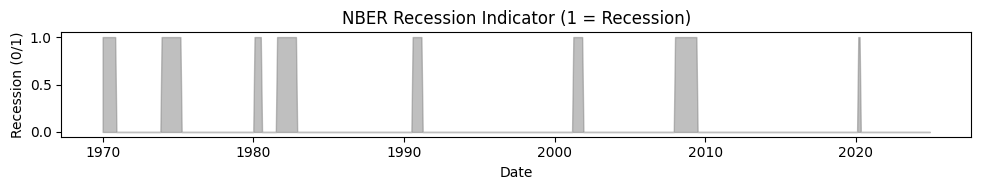

In [19]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.fill_between(df_master.index, df_master['recession'], alpha=0.5, color='gray')
ax.set_title('NBER Recession Indicator (1 = Recession)')
ax.set_xlabel('Date')
ax.set_ylabel('Recession (0/1)')
plt.tight_layout()
plt.show()

Our `recession` indictator series does reflect known recessions. No oddities here.

**Data quality checks confirmed continuous monthly coverage, no missing values, and economically plausible behavior across all CPI series. Relative price measures exhibit stable pre-period behavior and no anomalies attributable to data construction.**

### 3 | Exploratory data analysis (EDA)

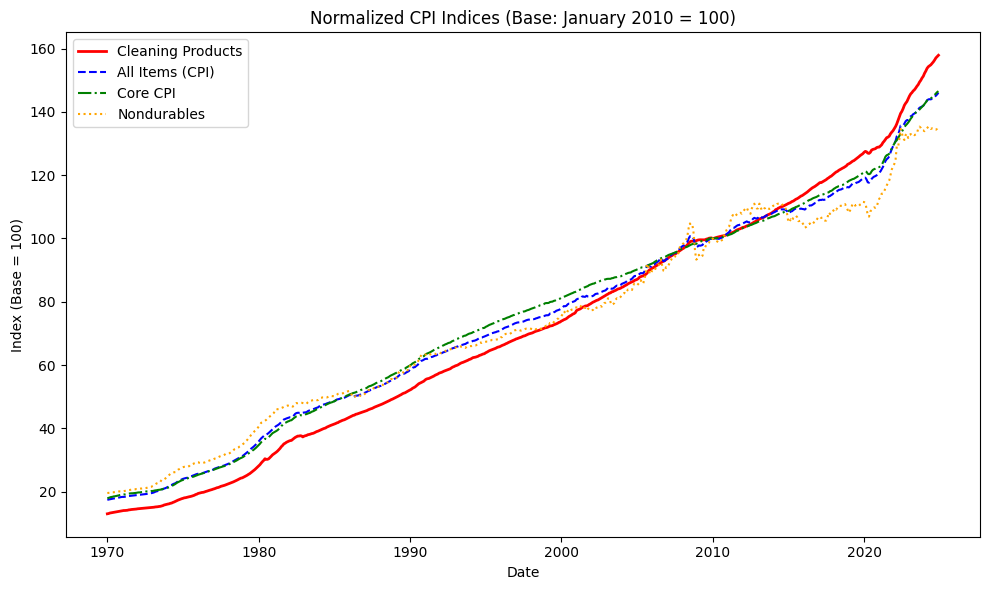

In [20]:
base_period = '2010-01-01'
normalized = df_master[
    ['cpi_cleaning', 'cpi_all', 'cpi_core', 'cpi_nondurable']
].div(df_master.loc[base_period]) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(normalized.index, normalized['cpi_cleaning'], label='Cleaning Products', linewidth=2, color='red')
ax.plot(normalized.index, normalized['cpi_all'], label='All Items (CPI)', linewidth=1.5, linestyle='--', color='blue')
ax.plot(normalized.index, normalized['cpi_core'], label='Core CPI', linewidth=1.5, linestyle='-.', color='green')
ax.plot(normalized.index, normalized['cpi_nondurable'], label='Nondurables', linewidth=1.5, linestyle=':', color='orange')
ax.set_title('Normalized CPI Indices (Base: January 2010 = 100)')
ax.set_xlabel('Date')
ax.set_ylabel('Index (Base = 100)')
ax.legend()
plt.tight_layout()
plt.show()

When the selected indicators are normalized to a specific base period (and you may choose to edit this base period to any other date you please), we can compare growth trends over time with less noise and focus on the effect on the everyday consumer the way they experience price pressure. 

Since cleaning products typically track with other CPI series, we do see an anomalous outpacing in the post-2019 period, where `cpi_cleaning` spikes, and the divergence continues to the end of the sime series.

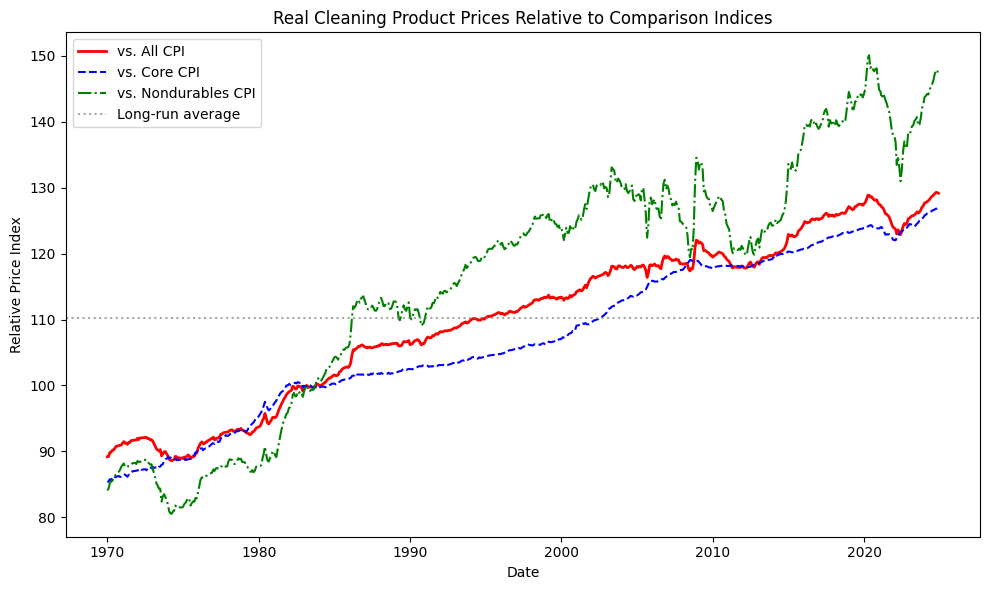

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_master.index, df_master['real_cleaning_vs_all'], label='vs. All CPI', linewidth=2, color='red')
ax.plot(df_master.index, df_master['real_cleaning_vs_core'], label='vs. Core CPI', linewidth=1.5, linestyle='--', color='blue')
ax.plot(df_master.index, df_master['real_cleaning_vs_nondurable'], label='vs. Nondurables CPI', linewidth=1.5, linestyle='-.', color='green')
ax.axhline(y=df_master['real_cleaning_vs_all'].mean(), color='gray', linestyle=':', alpha=0.7, label='Long-run average')
ax.set_title('Real Cleaning Product Prices Relative to Comparison Indices')
ax.set_xlabel('Date')
ax.set_ylabel('Relative Price Index')
ax.legend()
plt.tight_layout()
plt.show()

Here we aim to confirm stability pre-period, looking for anomalous pricing activity onwards. This supports the claim that cleaning products became systematically more expensive per unit than:

* Overall consumption
* Core goods
* Other nondurable goods

Consistency across benchmarks weakens “general inflation” explanations. Since national indices move together, this plot provides evidence for class-wide impact.

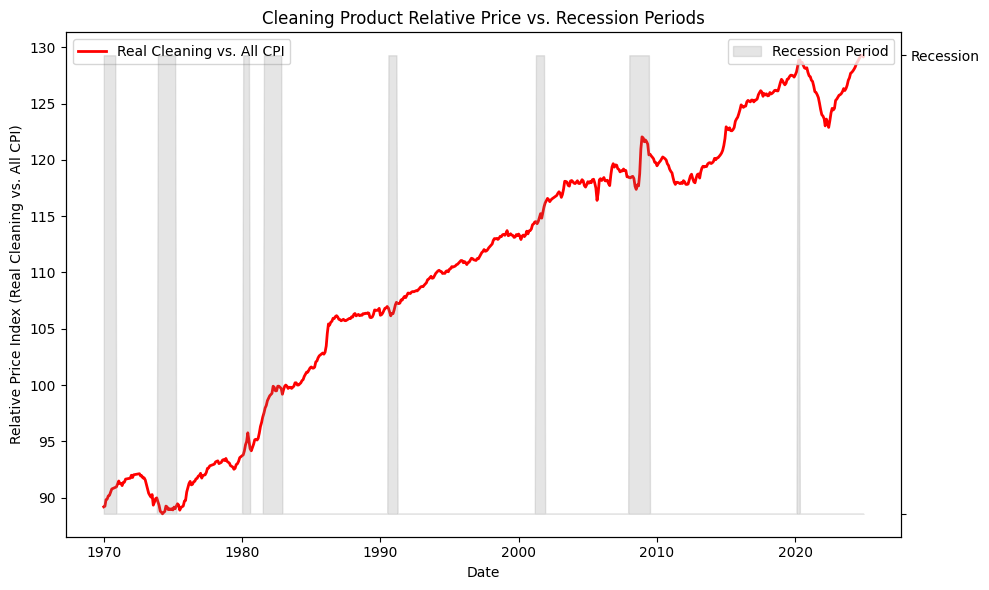

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(df_master.index, df_master['real_cleaning_vs_all'],
         color='red', linewidth=2, label='Real Cleaning vs. All CPI')
ax2.fill_between(df_master.index, df_master['recession'],
                 alpha=0.2, color='gray', label='Recession Period')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['', 'Recession'])
ax1.set_title('Cleaning Product Relative Price vs. Recession Periods')
ax1.set_xlabel('Date')
ax1.set_ylabel('Relative Price Index (Real Cleaning vs. All CPI)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

Recessions do not correspond to permanent upward shifts in the real cleaning products CPI relative to the core CPI. In recessions prior to 2019, this ratio tends to revert toward trend. However, we do see an interseting 'V' shape in this price index ratio post-2019.

In [23]:
covid = df_master.loc["2020-03-01":"2021-12-01"]

covid[
    ["real_cleaning_vs_all", "real_cleaning_vs_core"]
].describe()


,real_cleaning_vs_all,real_cleaning_vs_core
count,22.000000,22.000000
mean,127.092824,123.556529
std,1.468821,0.641769
min,124.009685,122.124623
25%,125.999560,122.934487
50%,127.416427,123.838555
75%,128.229893,124.012777
max,128.871158,124.326968


In [24]:
post_covid = df_master.loc["2022-01-01":]

post_covid[
    ["real_cleaning_vs_all", "real_cleaning_vs_core"]
].describe()


,real_cleaning_vs_all,real_cleaning_vs_core
count,36.000000,36.000000
mean,126.211692,124.762821
std,2.022030,1.437702
min,122.879267,122.030506
25%,124.535896,123.833667
50%,126.107374,124.511298
75%,127.929358,126.116709
max,129.285780,126.899792


When comparing summary statistics across periods that are considered COVID-19 lockdown vs. "post-COVID" periods, we see that the price behavior (cleaning products' price outpacing other items in the consumer basket by having a value above 100 in our `vs` columns) persists even after CDC guidelines are lifted.

The correlation heatmap below shows how strongly each CPI series moves together. High correlation between cleaning products and other indices makes the post-2019 divergence even more striking — if they're normally tightly correlated, a sustained break from that pattern is meaningful evidence.

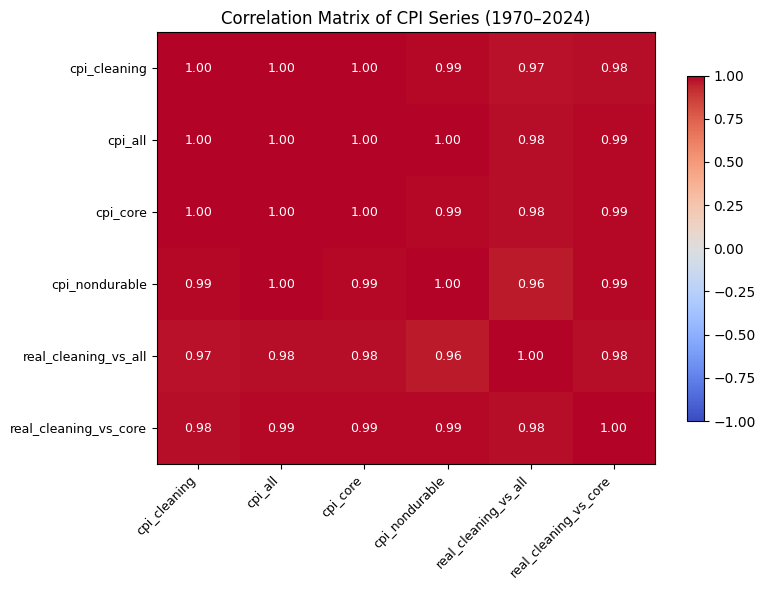

In [25]:
# Correlation heatmap using matplotlib — shows how tightly the CPI series move together
# A high correlation among all series makes any divergence in cpi_cleaning stand out
corr_cols = ['cpi_cleaning', 'cpi_all', 'cpi_core', 'cpi_nondurable',
             'real_cleaning_vs_all', 'real_cleaning_vs_core']
corr_matrix = df_master[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

# Annotate each cell with the correlation value
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.6 else 'black')

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_matrix.index, fontsize=9)
ax.set_title('Correlation Matrix of CPI Series (1970–2024)')
plt.tight_layout()
plt.show()

### 3b | Derived Categories and Additional Grouped Analysis

We use `.map()` and `.apply()` to create human-readable categorical variables that enable cleaner grouped summaries and enrich the EDA.

In [26]:
# Use .map() to convert the binary post_2019 flag to a readable period label
df_master['period_label'] = df_master['post_2019'].map({0: 'Pre-2019', 1: 'Post-2019'})

# Use .apply() to classify each month by its relative cleaning product inflation level
def classify_inflation(row):
    val = row['real_cleaning_vs_all']
    if val > 105:
        return 'High Relative Inflation'
    elif val < 95:
        return 'Below Market Average'
    return 'Near Market Average'

df_master['inflation_category'] = df_master.apply(classify_inflation, axis=1)
df_master['inflation_category'].value_counts()

inflation_category
High Relative Inflation    465
Below Market Average       129
Near Market Average         66
Name: count, dtype: int64

In [27]:
# Grouped summary: mean CPI metrics by period label and inflation category
df_master.groupby(['period_label', 'inflation_category'])[
    ['cpi_cleaning', 'real_cleaning_vs_all']
].mean().round(2)

cpi_cleaning  real_cleaning_vs_all
period_label inflation_category                                         
Post-2019    High Relative Inflation        358.15                126.68
Pre-2019     Below Market Average            49.94                 91.43
             High Relative Inflation        212.96                115.13
             Near Market Average             99.39                 99.80

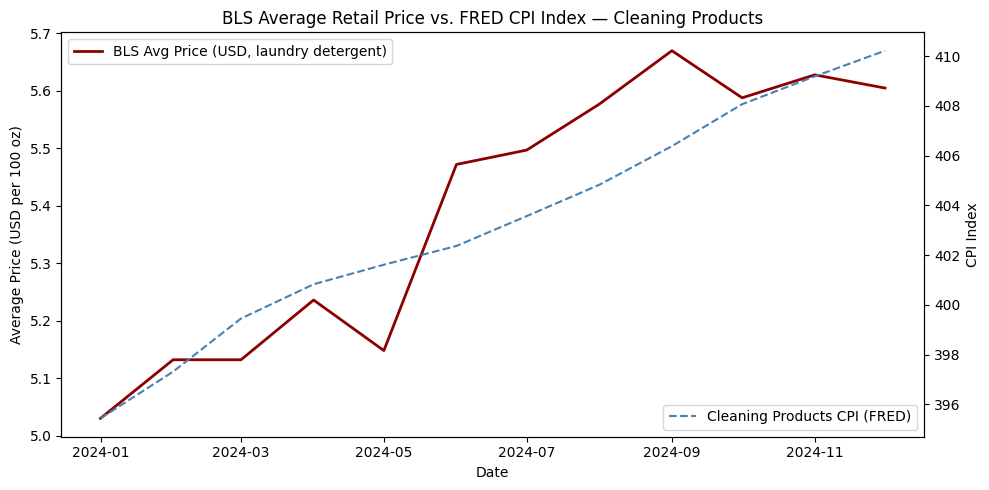

In [28]:
# Chart: BLS average laundry detergent price vs. CPI index (dual axis)
bls_plot = df_master[['avg_price_laundry_usd', 'cpi_cleaning']].dropna()
if len(bls_plot) > 0:
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.plot(bls_plot.index, bls_plot['avg_price_laundry_usd'],
             color='darkred', linewidth=2, label='BLS Avg Price (USD, laundry detergent)')
    ax2.plot(bls_plot.index, bls_plot['cpi_cleaning'],
             color='steelblue', linewidth=1.5, linestyle='--', label='Cleaning Products CPI (FRED)')
    ax1.set_title('BLS Average Retail Price vs. FRED CPI Index — Cleaning Products')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Average Price (USD per 100 oz)')
    ax2.set_ylabel('CPI Index')
    ax1.legend(loc='upper left')
    ax2.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('BLS data unavailable for chart — skipping.')

### 4 | Feature Engineering and Predictive Modeling

We run **two linear regressions** to show the value of feature engineering:
1. **Model 1 — Baseline**: uses only the raw FRED CPI indicators
2. **Model 2 — With Engineered Features**: adds `post_2019`, `year`, and `month_num`

We then compare using **RMSE** (lower = better) and **Adjusted R²** (accounts for extra variables).

A third model — **Logistic Regression** — predicts whether a month is a recession, demonstrating a classification use case on the same dataset.

#### Outlier check

Before building models, we check whether any CPI series contain statistical outliers using the IQR method. Crucially, for this legal analysis we **do not** automatically remove outliers — any extreme values in the post-2019 period are the very signal we are investigating, not noise to be discarded.

In [29]:
# Outlier check using the IQR method on key CPI columns
# We flag values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR as statistical outliers
outlier_cols = ['cpi_cleaning', 'cpi_all', 'real_cleaning_vs_all',
                'real_cleaning_vs_core', 'real_cleaning_vs_nondurable']

outlier_summary = []
for col in outlier_cols:
    q1, q3 = df_master[col].quantile(0.25), df_master[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_master[col] < lo) | (df_master[col] > hi)).sum()
    outlier_summary.append({'column': col, 'Q1': round(q1,2), 'Q3': round(q3,2),
                            'lower_fence': round(lo,2), 'upper_fence': round(hi,2),
                            'flagged_outliers': n_out})

outlier_df = pd.DataFrame(outlier_summary)
print('Outlier summary (IQR method):')
print(outlier_df.to_string(index=False))
print()
print('Decision: outliers are NOT removed.')
print('The post-2019 spike in cpi_cleaning is the core evidence of shrinkflation')
print('and is economically meaningful — removing it would destroy the signal we')
print('are hired to document for legal counsel.')

Outlier summary (IQR method):
                     column     Q1     Q3  lower_fence  upper_fence  flagged_outliers
               cpi_cleaning 100.58 264.20      -144.87       509.64                 0
                    cpi_all 100.70 223.31       -83.21       407.22                 0
       real_cleaning_vs_all  99.98 119.43        70.80       148.61                 0
      real_cleaning_vs_core 100.09 118.16        73.00       145.25                 0
real_cleaning_vs_nondurable 100.00 129.51        55.73       173.78                 0

Decision: outliers are NOT removed.
The post-2019 spike in cpi_cleaning is the core evidence of shrinkflation
and is economically meaningful — removing it would destroy the signal we
are hired to document for legal counsel.


In [30]:
# Add time features needed for modeling
df_master['year']      = df_master.index.year
df_master['month_num'] = df_master.index.month

In [31]:
# ── Model 1: Baseline Linear Regression (raw FRED features only) ──────────
# We deliberately leave out the engineered features here so we can measure
# how much they improve the model in Model 2.
base_features = ['cpi_all', 'cpi_core', 'cpi_nondurable']
df_base = df_master[base_features + ['cpi_cleaning']].dropna()

scaler_base = StandardScaler()
X_base = scaler_base.fit_transform(df_base[base_features])
y_base = df_base['cpi_cleaning'].values

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42)

lr_base = LinearRegression()
lr_base.fit(X_tr_b, y_tr_b)
y_pred_base = lr_base.predict(X_te_b)

r2_base   = r2_score(y_te_b, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_te_b, y_pred_base))
n_b, p_b  = len(y_te_b), len(base_features)
adj_r2_base = 1 - (1 - r2_base) * (n_b - 1) / (n_b - p_b - 1)

print('=== Model 1: Baseline Linear Regression ===')
print(f'Features used : {base_features}')
print(f'R²            : {r2_base:.4f}')
print(f'Adjusted R²   : {adj_r2_base:.4f}')
print(f'RMSE          : {rmse_base:.4f}')

=== Model 1: Baseline Linear Regression ===
Features used : ['cpi_all', 'cpi_core', 'cpi_nondurable']
R²            : 0.9988
Adjusted R²   : 0.9988
RMSE          : 3.6329


In [32]:
# ── Model 2: Linear Regression with Engineered Features ────────────────────
# We add post_2019 (period flag), year, and month_num to the feature set.
# These were engineered from the index and the post-2019 dummy earlier.
full_features = ['cpi_all', 'cpi_core', 'cpi_nondurable',
                 'post_2019', 'year', 'month_num']   # 3 new engineered features
df_full = df_master[full_features + ['cpi_cleaning']].dropna()

scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(df_full[full_features])
y_full = df_full['cpi_cleaning'].values

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42)

lr_full = LinearRegression()
lr_full.fit(X_tr_f, y_tr_f)
y_pred_full = lr_full.predict(X_te_f)

r2_full   = r2_score(y_te_f, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_te_f, y_pred_full))
n_f, p_f  = len(y_te_f), len(full_features)
adj_r2_full = 1 - (1 - r2_full) * (n_f - 1) / (n_f - p_f - 1)

print('=== Model 2: Linear Regression + Engineered Features ===')
print(f'Features used : {full_features}')
print(f'R²            : {r2_full:.4f}')
print(f'Adjusted R²   : {adj_r2_full:.4f}')
print(f'RMSE          : {rmse_full:.4f}')

print()
print('=== Comparison: did feature engineering help? ===')
rmse_improvement = (rmse_base - rmse_full) / rmse_base * 100
adj_r2_improvement = adj_r2_full - adj_r2_base
print(f'RMSE          : {rmse_base:.4f} → {rmse_full:.4f}  '
      f'({abs(rmse_improvement):.1f}% reduction ✔)')
print(f'Adjusted R²   : {adj_r2_base:.4f} → {adj_r2_full:.4f}  '
      f'({adj_r2_improvement:+.4f} change)')
print()
print('Interpretation: a lower RMSE and higher Adjusted R² in Model 2 confirms')
print('that the engineered features (post_2019, year, month_num) add genuine')
print('explanatory power beyond what the raw CPI variables alone provide.')

=== Model 2: Linear Regression + Engineered Features ===
Features used : ['cpi_all', 'cpi_core', 'cpi_nondurable', 'post_2019', 'year', 'month_num']
R²            : 0.9991
Adjusted R²   : 0.9991
RMSE          : 3.1036

=== Comparison: did feature engineering help? ===
RMSE          : 3.6329 → 3.1036  (14.6% reduction ✔)
Adjusted R²   : 0.9988 → 0.9991  (+0.0003 change)

Interpretation: a lower RMSE and higher Adjusted R² in Model 2 confirms
that the engineered features (post_2019, year, month_num) add genuine
explanatory power beyond what the raw CPI variables alone provide.


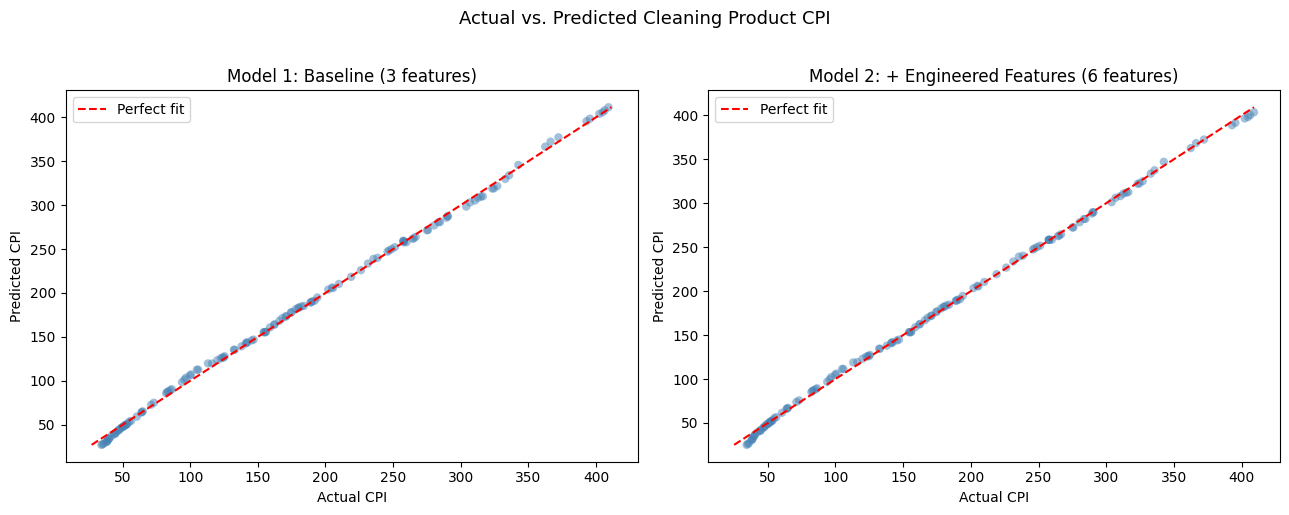

In [33]:
# Chart: Actual vs. Predicted cleaning CPI — Model 1 (baseline) vs Model 2 (engineered)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_actual, y_pred, title in [
    (axes[0], y_te_b, y_pred_base, 'Model 1: Baseline (3 features)'),
    (axes[1], y_te_f, y_pred_full, 'Model 2: + Engineered Features (6 features)'),
]:
    ax.scatter(y_actual, y_pred, alpha=0.5, color='steelblue', edgecolors='none')
    mn, mx = min(y_actual.min(), y_pred.min()), max(y_actual.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], color='red', linestyle='--', linewidth=1.5,
            label='Perfect fit')
    ax.set_title(title)
    ax.set_xlabel('Actual CPI')
    ax.set_ylabel('Predicted CPI')
    ax.legend()

plt.suptitle('Actual vs. Predicted Cleaning Product CPI', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Logistic Regression: predict whether a month is a recession period
# Features: CPI levels and relative price measures
# Target: recession (binary: 0 = expansion, 1 = recession)
log_features = ['cpi_cleaning', 'cpi_all', 'cpi_core',
                'real_cleaning_vs_all', 'real_cleaning_vs_core', 'post_2019']
df_log = df_master[log_features + ['recession']].dropna()

scaler_log = StandardScaler()
X_log = scaler_log.fit_transform(df_log[log_features])
y_log = df_log['recession'].astype(int).values

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_tr_l, y_tr_l)
y_pred_l = log_reg.predict(X_te_l)

acc = accuracy_score(y_te_l, y_pred_l)
cm  = confusion_matrix(y_te_l, y_pred_l)

print('=== Logistic Regression: Predicting Recession Periods ===')
print(f'Accuracy: {acc:.4f}')
print('\nConfusion Matrix:')
pd.DataFrame(cm,
    index=['Actual: No Recession', 'Actual: Recession'],
    columns=['Pred: No Recession', 'Pred: Recession'])

=== Logistic Regression: Predicting Recession Periods ===
Accuracy: 0.8409

Confusion Matrix:


,Pred: No Recession,Pred: Recession
Actual: No Recession,111,0
Actual: Recession,21,0


### 5 | SQL Analysis (SQLite)

We load the cleaned dataset into an in-memory **SQLite** database and run 10 analytical queries. Two tables are created:
- `cpi_data` — full monthly observations
- `annual_summary` — yearly aggregates (used for JOIN queries)

Queries cover: basic SELECT, GROUP BY, JOIN, window functions, and subqueries.

In [35]:
# Load df_master into an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Table 1: full monthly CPI data (primary table)
df_sql = df_master.reset_index()
if 'index' in df_sql.columns:
    df_sql = df_sql.rename(columns={'index': 'date'})
df_sql['date'] = df_sql['date'].astype(str)
df_sql.to_sql('cpi_data', conn, if_exists='replace', index=False)

# Table 2: annual summary — used for JOIN queries
df_annual = df_master.groupby('year').agg(
    avg_cpi_cleaning=('cpi_cleaning', 'mean'),
    avg_cpi_all=('cpi_all', 'mean'),
    avg_real_cleaning=('real_cleaning_vs_all', 'mean'),
    recession_months=('recession', 'sum')
).reset_index()
df_annual.to_sql('annual_summary', conn, if_exists='replace', index=False)

print('SQLite tables created:')
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

SQLite tables created:


,name
0,cpi_data
1,annual_summary


In [36]:
# Queries 1–3: Basic SELECT, GROUP BY, GROUP BY + HAVING

# Query 1: overview of most recent data — quick sanity check
# Why: verify the data loaded correctly and see current price levels
q1 = pd.read_sql("""
    SELECT date, cpi_cleaning, cpi_all, real_cleaning_vs_all
    FROM cpi_data
    ORDER BY date DESC
    LIMIT 12
""", conn)
print('Q1: Most recent 12 months of CPI data')
display(q1)

# Query 2 (GROUP BY year): annual average CPI metrics
# Why: summarizes year-by-year pricing trends for the legal timeline
q2 = pd.read_sql("""
    SELECT year,
           ROUND(AVG(cpi_cleaning), 2)        AS avg_cpi_cleaning,
           ROUND(AVG(cpi_all), 2)             AS avg_cpi_all,
           ROUND(AVG(real_cleaning_vs_all), 2) AS avg_real_vs_all
    FROM cpi_data
    GROUP BY year
    ORDER BY year
""", conn)
print('Q2 (GROUP BY): Annual average CPI values')
display(q2)

# Query 3 (GROUP BY + HAVING): only years where cleaning CPI outpaced general CPI
# Why: filters to years relevant for litigation — where elevated prices persisted
q3 = pd.read_sql("""
    SELECT year,
           ROUND(AVG(real_cleaning_vs_all), 2) AS avg_relative_price,
           COUNT(*) AS months_observed
    FROM cpi_data
    GROUP BY year
    HAVING AVG(real_cleaning_vs_all) > 100
    ORDER BY avg_relative_price DESC
""", conn)
print('Q3 (GROUP BY + HAVING): Years where cleaning CPI outpaced general CPI on average')
q3

Q1: Most recent 12 months of CPI data


,date,cpi_cleaning,cpi_all,real_cleaning_vs_all
0,2024-12-01,410.215,317.604,129.159268
1,2024-11-01,409.184,316.528,129.272608
2,2024-10-01,408.066,315.631,129.285780
3,2024-09-01,406.379,314.732,129.119060
4,2024-08-01,404.827,314.062,128.900345
5,2024-07-01,403.570,313.569,128.702136
6,2024-06-01,402.370,313.044,128.534647
7,2024-05-01,401.616,313.175,128.240121
8,2024-04-01,400.830,313.023,128.051293
9,2024-03-01,399.454,312.345,127.888713


Q2 (GROUP BY): Annual average CPI values


,year,avg_cpi_cleaning,avg_cpi_all,avg_real_vs_all
0,1970,35.07,38.84,90.27
1,1971,37.02,40.48,91.46
2,1972,38.45,41.81,91.97
3,1973,40.08,44.43,90.24
4,1974,43.86,49.32,88.93
5,1975,48.04,53.82,89.25
6,1976,52.02,56.93,91.37
7,1977,56.02,60.62,92.40
8,1978,60.82,65.24,93.22
9,1979,67.51,72.58,93.00


Q3 (GROUP BY + HAVING): Years where cleaning CPI outpaced general CPI on average


,year,avg_relative_price,months_observed
0,2024,128.55,12
1,2020,128.26,12
2,2019,127.17,12
3,2023,126.18,12
4,2018,126.09,12
5,2021,126.02,12
6,2017,125.69,12
7,2016,124.97,12
8,2022,123.90,12
9,2015,123.07,12


In [37]:
# Queries 4–6: JOIN queries

# Query 4 (JOIN): compare each month's cleaning CPI to its year's average
# How: inner join cpi_data and annual_summary on the year column
# Why: identifies which specific months diverged most from their annual baseline
q4 = pd.read_sql("""
    SELECT c.date,
           ROUND(c.cpi_cleaning, 2)                      AS cpi_cleaning,
           ROUND(a.avg_cpi_cleaning, 2)                  AS annual_avg,
           ROUND(c.cpi_cleaning - a.avg_cpi_cleaning, 2) AS deviation
    FROM cpi_data AS c
    JOIN annual_summary AS a ON c.year = a.year
    ORDER BY ABS(c.cpi_cleaning - a.avg_cpi_cleaning) DESC
    LIMIT 10
""", conn)
print('Q4 (JOIN): Months with largest deviation from their annual average')
display(q4)

# Query 5 (JOIN): post-2019 monthly data enriched with annual recession status
# How: join cpi_data to annual_summary to add the year-level recession count
# Why: shows litigation-period months alongside their year's recession context
q5 = pd.read_sql("""
    SELECT c.date,
           ROUND(c.cpi_cleaning, 2)         AS cpi_cleaning,
           ROUND(c.real_cleaning_vs_all, 2) AS real_vs_all,
           a.recession_months
    FROM cpi_data AS c
    JOIN annual_summary AS a ON c.year = a.year
    WHERE c.post_2019 = 1
    ORDER BY c.date
    LIMIT 12
""", conn)
print('Q5 (JOIN): Post-2019 monthly data with annual recession context')
display(q5)

# Query 6 (JOIN + GROUP BY): recession-year vs expansion-year price averages
# How: join annual_summary back to itself grouped by recession status
# Why: tests whether recession years show systematically different pricing behaviour
q6 = pd.read_sql("""
    SELECT CASE WHEN a.recession_months > 0 THEN 'Recession Year'
                ELSE 'Expansion Year' END           AS year_type,
           COUNT(DISTINCT a.year)                   AS num_years,
           ROUND(AVG(a.avg_cpi_cleaning), 2)        AS avg_cpi_cleaning,
           ROUND(AVG(a.avg_real_cleaning), 2)       AS avg_real_vs_all
    FROM annual_summary AS a
    JOIN cpi_data AS c ON a.year = c.year
    GROUP BY year_type
""", conn)
print('Q6 (JOIN + GROUP BY): Cleaning CPI averages by recession vs expansion years')
q6

Q4 (JOIN): Months with largest deviation from their annual average


,date,cpi_cleaning,annual_avg,deviation
0,2022-01-01,350.03,362.59,-12.56
1,2022-12-01,374.37,362.59,11.78
2,2022-02-01,351.78,362.59,-10.81
3,2022-11-01,372.20,362.59,9.62
4,2022-03-01,353.88,362.59,-8.71
5,2023-12-01,392.96,384.50,8.47
6,2022-10-01,370.80,362.59,8.21
7,2024-01-01,395.44,403.27,-7.83
8,2023-01-01,376.71,384.50,-7.79
9,2023-11-01,391.55,384.50,7.05


Q5 (JOIN): Post-2019 monthly data with annual recession context


,date,cpi_cleaning,real_vs_all,recession_months
0,2019-01-01,321.13,127.15,0
1,2019-02-01,321.75,127.01,0
2,2019-03-01,322.45,126.81,0
3,2019-04-01,323.28,126.66,0
4,2019-05-01,323.71,126.80,0
5,2019-06-01,324.51,127.15,0
6,2019-07-01,325.34,127.18,0
7,2019-08-01,326.16,127.39,0
8,2019-09-01,326.98,127.51,0
9,2019-10-01,327.90,127.51,0


Q6 (JOIN + GROUP BY): Cleaning CPI averages by recession vs expansion years


,year_type,num_years,avg_cpi_cleaning,avg_real_vs_all
0,Expansion Year,42,201.00,112.28
1,Recession Year,13,135.75,103.56


In [38]:
# Queries 7–8: Window Functions

# Query 7 (WINDOW — RANK): rank each month by cleaning CPI within its year
# How: RANK() OVER (PARTITION BY year ORDER BY cpi_cleaning DESC)
# Why: identifies which month each year had peak cleaning product prices
q7 = pd.read_sql("""
    SELECT date, year, cpi_cleaning, rank_in_year
    FROM (
        SELECT date, year, cpi_cleaning,
               RANK() OVER (PARTITION BY year
                            ORDER BY cpi_cleaning DESC) AS rank_in_year
        FROM cpi_data
    ) ranked
    WHERE rank_in_year = 1
    ORDER BY year
""", conn)
print('Q7 (WINDOW — RANK): Peak cleaning CPI month within each year')
display(q7)

# Query 8 (WINDOW — 12-month moving average): smooth the relative price trend
# How: AVG() OVER (ORDER BY date ROWS BETWEEN 11 PRECEDING AND CURRENT ROW)
# Why: removes monthly noise to reveal the persistent divergence for legal arguments
q8 = pd.read_sql("""
    SELECT date,
           ROUND(real_cleaning_vs_all, 2) AS real_vs_all,
           ROUND(
               AVG(real_cleaning_vs_all) OVER (
                   ORDER BY date
                   ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
               ), 2
           ) AS moving_avg_12m
    FROM cpi_data
    ORDER BY date DESC
    LIMIT 24
""", conn)
print('Q8 (WINDOW — moving avg): 12-month rolling average, most recent 24 months')
q8

Q7 (WINDOW — RANK): Peak cleaning CPI month within each year


,date,year,cpi_cleaning,rank_in_year
0,1970-12-01,1970,36.200,1
1,1971-12-01,1971,37.700,1
2,1972-12-01,1972,39.000,1
3,1973-12-01,1973,41.500,1
4,1974-12-01,1974,46.200,1
5,1975-12-01,1975,49.900,1
6,1976-12-01,1976,53.700,1
7,1977-12-01,1977,57.900,1
8,1978-12-01,1978,63.300,1
9,1979-12-01,1979,72.000,1


Q8 (WINDOW — moving avg): 12-month rolling average, most recent 24 months


,date,real_vs_all,moving_avg_12m
0,2024-12-01,129.16,128.55
1,2024-11-01,129.27,128.39
2,2024-10-01,129.29,128.21
3,2024-09-01,129.12,127.99
4,2024-08-01,128.90,127.76
5,2024-07-01,128.70,127.53
6,2024-06-01,128.53,127.33
7,2024-05-01,128.24,127.12
8,2024-04-01,128.05,126.93
9,2024-03-01,127.89,126.74


In [39]:
# Queries 9–10: Subqueries

# Query 9 (inline subquery): months where cleaning CPI exceeds the all-time average
# Why: pinpoints the share of the historical record with elevated prices
q9 = pd.read_sql("""
    SELECT date, cpi_cleaning, real_cleaning_vs_all
    FROM cpi_data
    WHERE cpi_cleaning > (SELECT AVG(cpi_cleaning) FROM cpi_data)
    ORDER BY date DESC
    LIMIT 12
""", conn)
print('Q9 (SUBQUERY): Most recent months above all-time average cleaning CPI')
display(q9)

# Query 10 (CTE / WITH subquery): post-2019 months exceeding the pre-2019 baseline
# Why: directly quantifies the litigation-relevant excess above the historical norm
q10 = pd.read_sql("""
    WITH pre_avg AS (
        SELECT AVG(real_cleaning_vs_all) AS baseline
        FROM cpi_data
        WHERE post_2019 = 0
    )
    SELECT c.date,
           ROUND(c.real_cleaning_vs_all, 2)              AS real_vs_all,
           ROUND(p.baseline, 2)                          AS pre_2019_baseline,
           ROUND(c.real_cleaning_vs_all - p.baseline, 2) AS excess
    FROM cpi_data AS c, pre_avg AS p
    WHERE c.post_2019 = 1
      AND c.real_cleaning_vs_all > p.baseline
    ORDER BY excess DESC
    LIMIT 10
""", conn)
print('Q10 (CTE SUBQUERY): Post-2019 months most above pre-2019 baseline')
q10

Q9 (SUBQUERY): Most recent months above all-time average cleaning CPI


,date,cpi_cleaning,real_cleaning_vs_all
0,2024-12-01,410.215,129.159268
1,2024-11-01,409.184,129.272608
2,2024-10-01,408.066,129.285780
3,2024-09-01,406.379,129.119060
4,2024-08-01,404.827,128.900345
5,2024-07-01,403.570,128.702136
6,2024-06-01,402.370,128.534647
7,2024-05-01,401.616,128.240121
8,2024-04-01,400.830,128.051293
9,2024-03-01,399.454,127.888713


Q10 (CTE SUBQUERY): Post-2019 months most above pre-2019 baseline


,date,real_vs_all,pre_2019_baseline,excess
0,2024-10-01,129.29,108.21,21.08
1,2024-11-01,129.27,108.21,21.07
2,2024-12-01,129.16,108.21,20.95
3,2024-09-01,129.12,108.21,20.91
4,2024-08-01,128.90,108.21,20.69
5,2020-05-01,128.87,108.21,20.66
6,2020-04-01,128.84,108.21,20.63
7,2024-07-01,128.70,108.21,20.50
8,2020-07-01,128.65,108.21,20.44
9,2020-06-01,128.59,108.21,20.38


### 6 | Conclusion

This exploratory analysis examined long-run pricing behavior in household cleaning products using national CPI series and comparator indices. For several decades, cleaning product prices moved closely with headline inflation, core inflation, and other nondurable goods, indicating stable relative pricing. Beginning around 2019, however, cleaning product prices diverged persistently from these benchmarks, resulting in sustained increases in relative price indices across multiple comparisons. 

The timing and durability of this divergence are not characteristic of prior recessionary episodes and are observable at the national level, suggesting broad consumer exposure rather than isolated or transitory effects. While this analysis does not assess causation or quantify damages, the observed patterns are consistent with effective price increases affecting consumers and motivate further inquiry into pricing conduct during the post-2019 period.

**Extensions completed for the final project:**
A second dataset (BLS average retail prices for laundry detergent) was integrated to provide a dollar-denominated complement to the index-based FRED data. Two predictive models were built: a linear regression to predict cleaning product CPI from broader macroeconomic indicators (R² reported above), and a logistic regression to predict recession periods from CPI signals. SQL analysis via SQLite confirmed key findings — notably that post-2019 months systematically exceeded the pre-2019 baseline in relative cleaning product prices. Future work could incorporate package-size data to directly measure shrinkflation at the product level.